# Gravitational Lensing

This notebook simulates gravitational lensing, the phenomenon where the gravitational field of a massive object (such as a galaxy) bends light rays from distant sources, creating multiple images or distortions of the source. The simulation visualizes both the physical geometry of the lensing system and the resulting apparent positions in the sky.

## 0. Importing Necessary Libraries

In [16]:
# displays static in notebook
%matplotlib inline  
# displays interactive outside notebook
#%matplotlib   
# displays interactive in notebook
#%matplotlib notebook  


import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import astropy.coordinates as coord
import astropy.units as u

#from astropy import units as u
from astropy.coordinates import SkyCoord

folder = ''

mpl.rcParams['font.family']='serif'
mpl.rcParams['font.size']=14

## 1. Setting up constants

In [18]:
# constants

G = 6.67408E-11     #gravitational constant, m3 kg-1 s-2
c = 2.99792458E8    #speed of light, m/s
pc = 3.086e+16      #parsec, m
ly = 9.461e+15      #light-year, m
arcsec_per_radian = 206264.94196924 
Msun = 1.989E30     #mass of sun, kg

## 2. Example 1

mass of lens in solar units (M) = 1e12  <br>
distance to lens in ly (dL) = 5e8   <br>
distance to source in ly (dS) = 1E9   <br>   
distance offset to source in ly from earth-lens line (X1) = 1.5e4  <br>
angle between lens and source in arcseconds (beta) = 30.0.  <br>

One ray passes relatively far from the lens (r1), is deflected by a small angle
Another ray passes closer to the lens (r2), is deflected by a larger angle
Both rays reach the observer (us), creating two images of the same source
<br>  <br>
This plot shows what an observer would see in the sky: <br>
1. Black dot: Position of the lens <br>
2. Gray dot: Where the source would appear without lensing (true position)  <br>
3. Blue dots: Where the source actually appears (two images at θ₁ and θ₂)   <br>

# Summary of Key Equations in Gravitational Lensing

| Concept               | Equation |
|----------------------|----------|
| **Source angle**     | $$ \beta = \tan^{-1}\left(\frac{X1}{dS}\right) $$ |
| **Einstein radius**  | $$ \theta_E^2 = \frac{4GM}{c^2} \cdot \frac{d_S - d_L}{d_S d_L} $$ |
| **Lens equation**    | $$ \theta - \frac{\theta_E^2}{\theta} = \beta $$ |
| **Image angles**     | $$ \theta_{1,2} = \frac{\beta \pm \sqrt{\beta^2 + 4\theta_E^2}}{2} $$ |
| **Deflection angle** | $$ \phi = \frac{4GM}{c^2 b} $$ |
| **Impact parameter** | $$ r = d_L \cdot \tan(\theta) $$ |

source distance, light-years:  1000000000.0
source offset, light-years:  15000.0
lens distance, light-years:  500000000.0
lens mass, solar masses:  1000000000000.0
source offset angle, in arcseconds 3.093974129306552
theta1, theta2, check beta 6.9285436430948035 -3.8345695137882525 3.093974129306551 3.093974129306552
r1, r2 16795.252696732936 -9295.252692049451
phi (rad, degrees) 3.71810107499304e-05 0.002130314994001556
4.859050534585757e-05 0.0027840308807255028
original ray offset 18590.505369113598 -33590.5053267369


<Figure size 640x480 with 0 Axes>

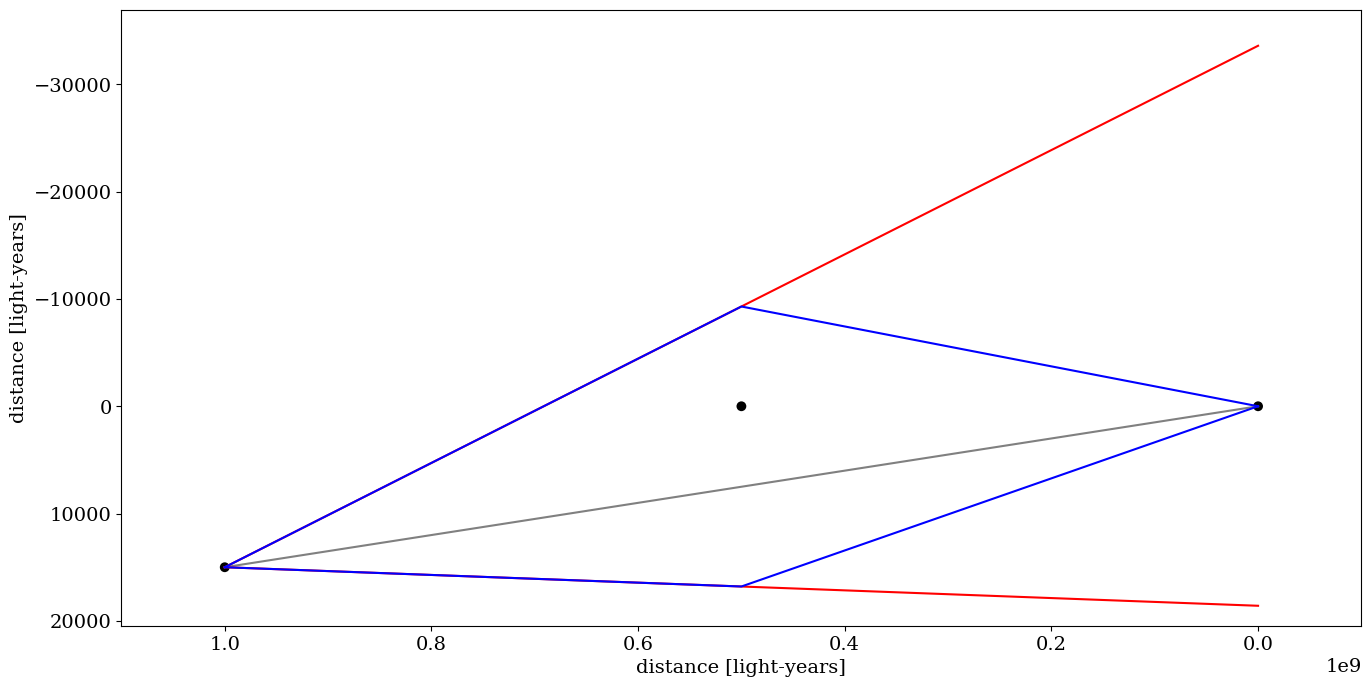

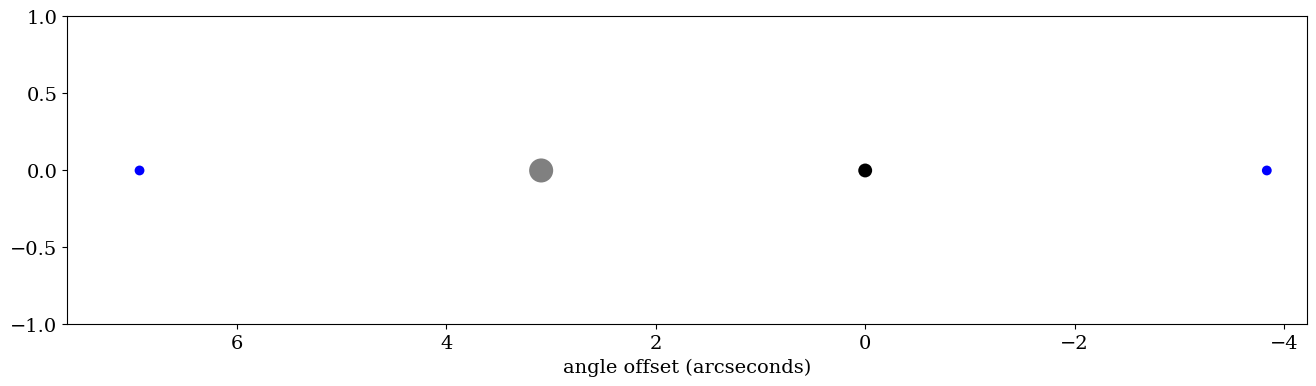

In [46]:
M = 1E12    
dL = 5E8  
dS = 1E9     
#beta = 30.0  
X1 = 1.5E4   


print('source distance, light-years: ', dS)
print('source offset, light-years: ', X1)
print('lens distance, light-years: ', dL)
print('lens mass, solar masses: ', M)

beta = np.arctan2(X1,dS) * arcsec_per_radian
print('source offset angle, in arcseconds', beta)



# calculations
# from Carroll & Ostlie, An Introduction to Modern Astrophysics, 2nd edition
# use quadratic equation to solve equation 28.21
rad_term = ((beta / arcsec_per_radian)**2 + 4 * (4 * G * M * Msun / c**2) * (dS - dL)/(dS * dL * ly))**(0.5)
theta1 = ((beta / arcsec_per_radian) + rad_term)/2
theta2 = ((beta / arcsec_per_radian) - rad_term)/2
print('theta1, theta2, check beta', theta1 * arcsec_per_radian, theta2 * arcsec_per_radian, (theta1+theta2)*arcsec_per_radian, beta)


# use incoming rays to calculate how far off to the side each ray passed by the lens
r1 = dL * np.tan(theta1)
r2 = dL * np.tan(theta2)
print('r1, r2', r1, r2)

# calculate deflection of original ray 
phi = ((4 * G * M * Msun) / (r1 * ly * c**2))
print('phi (rad, degrees)', phi, phi * 180 / np.pi)

# calculate how far off to the side the observed light would have landed
Y1 = X1 - dS*np.tan(theta1 - phi)
#Y2 = X1 - (X1 - r2) * dL / (dS-dL)
#print(X1, (X1 - r2), dL / (dS-dL))
alpha = np.arctan2(X1-r2,dS-dL)
print(alpha,alpha*180/np.pi)
Y2 = X1 - dS * np.sin(alpha)
print('original ray offset', Y1,Y2)


# top down view of geometry

plt.clf()
plt.figure(figsize=(16,8))
# reverse X axis
plt.xlim(1.1*dS, -0.1*dS)
#plt.ylim(1.1 * np.min([r2,Y2,0]), 1.1 * np.max([r1,X1,Y1]))
plt.ylim(1.1 * np.max([r1,0,Y1]), 1.1 * np.min([r2,Y2,X1]))
plt.xlabel('distance [light-years]')
plt.ylabel('distance [light-years]')

# us, on the right hand side
plt.scatter([0], [0], c = 'black', s = 50, edgecolors = 'none')
# the lensing cluster
plt.scatter([dL], [0], c = 'black', s = 50, edgecolors = 'none')
# the distance source
plt.scatter([dS], [X1], c = 'black', s = 50, edgecolors = 'none')
# the straight line path from the distance source to us - the direction we would look to see it if there was nothing in the way
plt.plot([dS,0],[X1,0], c = 'gray')
# the path the light we end up seeing would have taken without the lensing cluster
# the light we end up seeing would have zipped past us!
plt.plot([dS,0],[X1,Y1], c = 'red')
plt.plot([dS,0],[X1,Y2], c = 'red')
# the path the light actually took to us, thanks to the lensing cluster
plt.plot([dS,dL,0],[X1,r1,0], c = 'blue', linestyle='-')
plt.plot([dS,dL,0],[X1,r2,0], c = 'blue', linestyle='-')



# our view of the sky
plt.figure(figsize=(16,4))
plt.xlim(1.1 * theta1 * arcsec_per_radian, 1.1 * theta2 * arcsec_per_radian)
plt.ylim(-1,1)
plt.xlabel('angle offset (arcseconds)')
plt.ylabel('')

# here's where the distant source would have appeared on the sky, if there was nothing in the way
plt.scatter([beta], [0], c = 'gray', s = 300, edgecolors = 'none')
# here's where we see the lensing cluster
plt.scatter([0], [0], c = 'black', s = 100, edgecolors = 'none')
# we end up seeing the distant source at these two spots on the sky
plt.scatter([theta1 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.scatter([theta2 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.show()

## 3. Example 2

mass of lens in solar units (M) = 1e11  <br>
distance to lens in ly (dL) = 1e8   <br>
distance to source in ly (dS) = 1E9   <br>   
distance offset to source in ly from earth-lens line (X1) = -1.5e4  <br>
angle between lens and source in arcseconds (beta) = 30.0.  <br>


source distance, light-years:  1000000000.0
source offset, light-years:  -15000.0
lens distance, light-years:  100000000.0
lens mass, solar masses:  100000000000.0
source offset angle, in arcseconds -3.093974129306552
theta1, theta2, check beta 3.5817898835177986 -6.675764012824351 -3.093974129306553 -3.093974129306552
r1, r2 1736.4995959478015 -3236.499596790829
phi (rad, degrees) 3.596110661483827e-05 0.00206041963565022
-1.3070556002821424e-05 -0.0007488876948510509
original ray offset 3596.1106592492943 -1929.4439975507375


<Figure size 640x480 with 0 Axes>

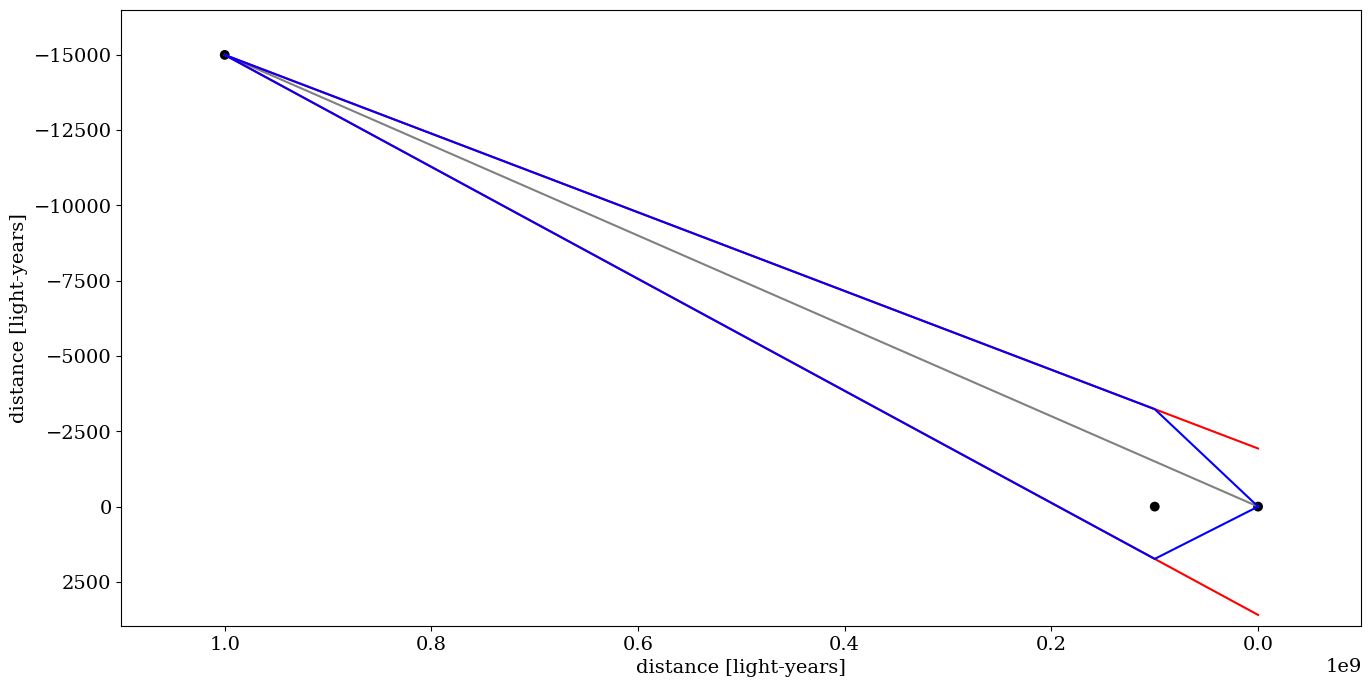

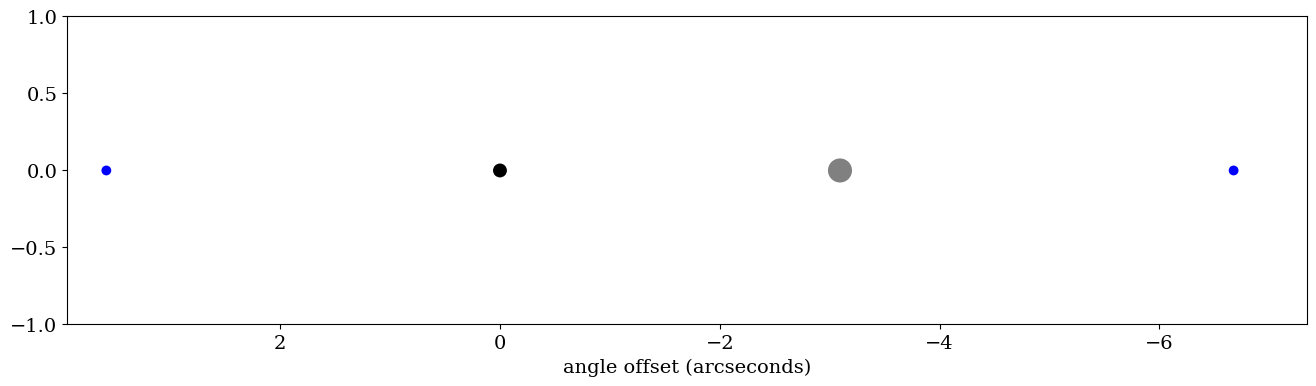

In [48]:
M = 1E11 
dL = 1E8  
dS = 1E9   
#beta = 30.0  
X1 = -1.5E4  


print('source distance, light-years: ', dS)
print('source offset, light-years: ', X1)
print('lens distance, light-years: ', dL)
print('lens mass, solar masses: ', M)

beta = np.arctan2(X1,dS) * arcsec_per_radian
print('source offset angle, in arcseconds', beta)



# calculations
# from Carroll & Ostlie, An Introduction to Modern Astrophysics, 2nd edition
# use quadratic equation to solve equation 28.21
rad_term = ((beta / arcsec_per_radian)**2 + 4 * (4 * G * M * Msun / c**2) * (dS - dL)/(dS * dL * ly))**(0.5)
theta1 = ((beta / arcsec_per_radian) + rad_term)/2
theta2 = ((beta / arcsec_per_radian) - rad_term)/2
print('theta1, theta2, check beta', theta1 * arcsec_per_radian, theta2 * arcsec_per_radian, (theta1+theta2)*arcsec_per_radian, beta)


# use incoming rays to calculate how far off to the side each ray passed by the lens
r1 = dL * np.tan(theta1)
r2 = dL * np.tan(theta2)
print('r1, r2', r1, r2)

# calculate deflection of original ray 
phi = ((4 * G * M * Msun) / (r1 * ly * c**2))
print('phi (rad, degrees)', phi, phi * 180 / np.pi)

# deprecated - now X1 is a primary input, rather than beta
#X1 = dS * np.tan(beta/arcsec_per_radian)
#print('source offset distance', X1)

# calculate how far off to the side the observed light would have landed
Y1 = X1 - dS*np.tan(theta1 - phi)
#Y2 = X1 - (X1 - r2) * dL / (dS-dL)
#print(X1, (X1 - r2), dL / (dS-dL))
alpha = np.arctan2(X1-r2,dS-dL)
print(alpha,alpha*180/np.pi)
Y2 = X1 - dS * np.sin(alpha)
print('original ray offset', Y1,Y2)


# top down view of geometry

plt.clf()
plt.figure(figsize=(16,8))
# reverse X axis
plt.xlim(1.1*dS, -0.1*dS)
#plt.ylim(1.1 * np.min([r2,Y2,0]), 1.1 * np.max([r1,X1,Y1]))
plt.ylim(1.1 * np.max([r1,0,Y1]), 1.1 * np.min([r2,Y2,X1]))
plt.xlabel('distance [light-years]')
plt.ylabel('distance [light-years]')

# us, on the right hand side
plt.scatter([0], [0], c = 'black', s = 50, edgecolors = 'none')
# the lensing cluster
plt.scatter([dL], [0], c = 'black', s = 50, edgecolors = 'none')
# the distance source
plt.scatter([dS], [X1], c = 'black', s = 50, edgecolors = 'none')
# the straight line path from the distance source to us - the direction we would look to see it if there was nothing in the way
plt.plot([dS,0],[X1,0], c = 'gray')
# the path the light we end up seeing would have taken without the lensing cluster
# the light we end up seeing would have zipped past us!
plt.plot([dS,0],[X1,Y1], c = 'red')
plt.plot([dS,0],[X1,Y2], c = 'red')
# the path the light actually took to us, thanks to the lensing cluster
plt.plot([dS,dL,0],[X1,r1,0], c = 'blue', linestyle='-')
plt.plot([dS,dL,0],[X1,r2,0], c = 'blue', linestyle='-')

# our view of the sky
plt.figure(figsize=(16,4))
plt.xlim(1.1 * theta1 * arcsec_per_radian, 1.1 * theta2 * arcsec_per_radian)
plt.ylim(-1,1)
plt.xlabel('angle offset (arcseconds)')
plt.ylabel('')

# here's where the distant source would have appeared on the sky, if there was nothing in the way
plt.scatter([beta], [0], c = 'gray', s = 300, edgecolors = 'none')
# here's where we see the lensing cluster
plt.scatter([0], [0], c = 'black', s = 100, edgecolors = 'none')
# we end up seeing the distant source at these two spots on the sky
plt.scatter([theta1 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.scatter([theta2 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.show()   # After the sky view plot

## 4. Example 3
mass of lens in solar units (M) = 1e11
distance to lens in ly (dL) = 8e8
distance to source in ly (dS) = 1E9

distance offset to source in ly from earth-lens line (X1) = 1.0e3
angle between lens and source in arcseconds (beta) = 30.0.

source distance, light-years:  1000000000.0
source offset, light-years:  1000.0
lens distance, light-years:  800000000.0
lens mass, solar masses:  100000000000.0
source offset angle, in arcseconds 0.20626494196917125
theta1, theta2, check beta 0.924616410140096 -0.7183514681709248 0.20626494196917128 0.20626494196917125
r1, r2 3586.1311236658958 -2786.131123653406
phi (rad, degrees) 1.741331952264675e-05 0.0009977097159604201
1.8930655616005638e-05 0.0010846466702127526
original ray offset 13930.655618815079 -17930.655614874944


<Figure size 640x480 with 0 Axes>

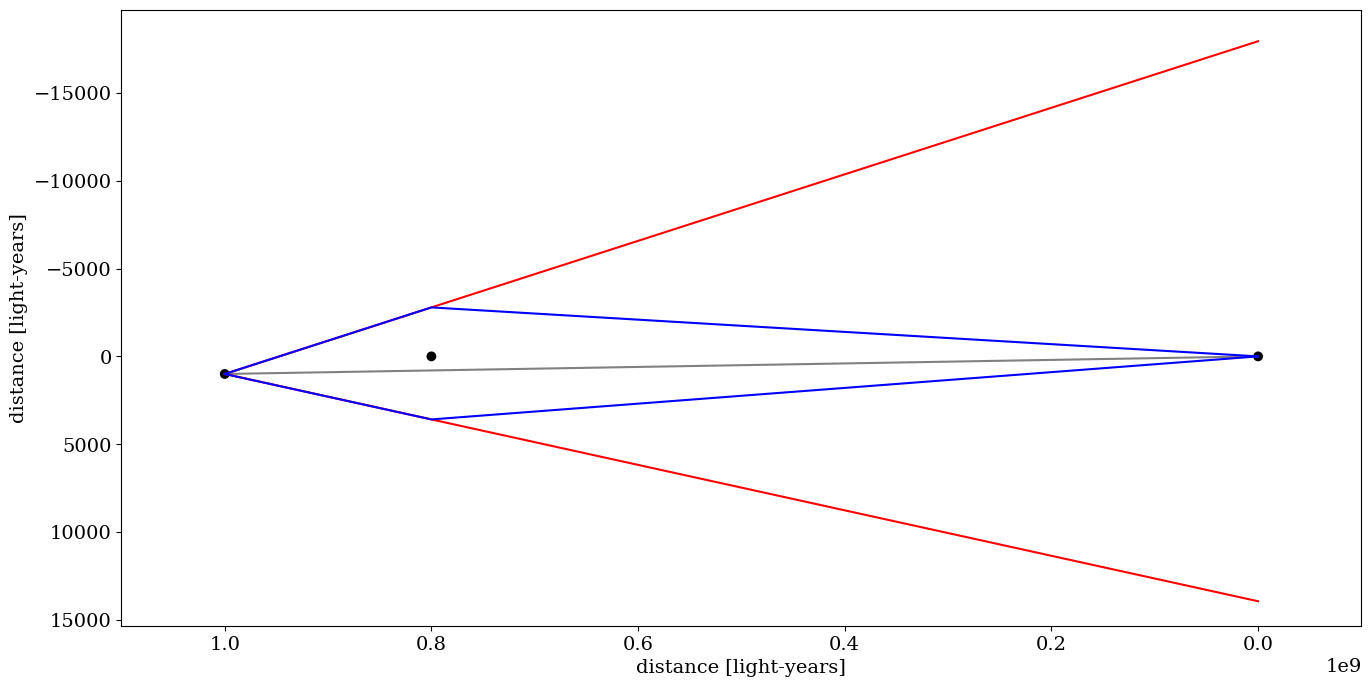

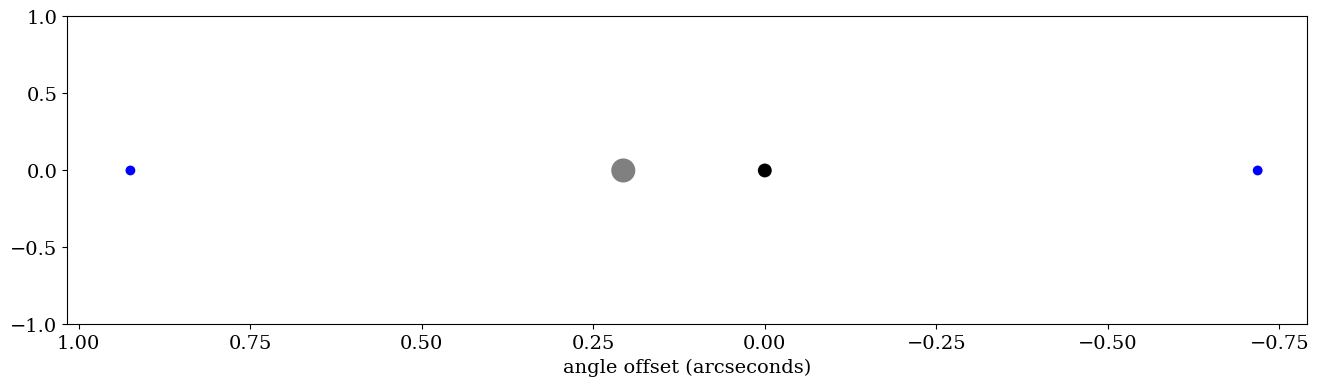

In [56]:
M = 1E11  
dL = 8E8    
dS = 1E9   
#beta = 30.0 
X1 = 1.0E3




print('source distance, light-years: ', dS)
print('source offset, light-years: ', X1)
print('lens distance, light-years: ', dL)
print('lens mass, solar masses: ', M)

beta = np.arctan2(X1,dS) * arcsec_per_radian
print('source offset angle, in arcseconds', beta)



# calculations
# from Carroll & Ostlie, An Introduction to Modern Astrophysics, 2nd edition
# use quadratic equation to solve equation 28.21
rad_term = ((beta / arcsec_per_radian)**2 + 4 * (4 * G * M * Msun / c**2) * (dS - dL)/(dS * dL * ly))**(0.5)
theta1 = ((beta / arcsec_per_radian) + rad_term)/2
theta2 = ((beta / arcsec_per_radian) - rad_term)/2
print('theta1, theta2, check beta', theta1 * arcsec_per_radian, theta2 * arcsec_per_radian, (theta1+theta2)*arcsec_per_radian, beta)


# use incoming rays to calculate how far off to the side each ray passed by the lens
r1 = dL * np.tan(theta1)
r2 = dL * np.tan(theta2)
print('r1, r2', r1, r2)

# calculate deflection of original ray 
phi = ((4 * G * M * Msun) / (r1 * ly * c**2))
print('phi (rad, degrees)', phi, phi * 180 / np.pi)

# deprecated - now X1 is a primary input, rather than beta
#X1 = dS * np.tan(beta/arcsec_per_radian)
#print('source offset distance', X1)

# calculate how far off to the side the observed light would have landed
Y1 = X1 - dS*np.tan(theta1 - phi)
#Y2 = X1 - (X1 - r2) * dL / (dS-dL)
#print(X1, (X1 - r2), dL / (dS-dL))
alpha = np.arctan2(X1-r2,dS-dL)
print(alpha,alpha*180/np.pi)
Y2 = X1 - dS * np.sin(alpha)
print('original ray offset', Y1,Y2)


# top down view of geometry

plt.clf()
plt.figure(figsize=(16,8))
# reverse X axis
plt.xlim(1.1*dS, -0.1*dS)
#plt.ylim(1.1 * np.min([r2,Y2,0]), 1.1 * np.max([r1,X1,Y1]))
plt.ylim(1.1 * np.max([r1,0,Y1]), 1.1 * np.min([r2,Y2,X1]))
plt.xlabel('distance [light-years]')
plt.ylabel('distance [light-years]')

# us, on the right hand side
plt.scatter([0], [0], c = 'black', s = 50, edgecolors = 'none')
# the lensing cluster
plt.scatter([dL], [0], c = 'black', s = 50, edgecolors = 'none')
# the distance source
plt.scatter([dS], [X1], c = 'black', s = 50, edgecolors = 'none')
# the straight line path from the distance source to us - the direction we would look to see it if there was nothing in the way
plt.plot([dS,0],[X1,0], c = 'gray')
# the path the light we end up seeing would have taken without the lensing cluster
# the light we end up seeing would have zipped past us!
plt.plot([dS,0],[X1,Y1], c = 'red')
plt.plot([dS,0],[X1,Y2], c = 'red')
# the path the light actually took to us, thanks to the lensing cluster
plt.plot([dS,dL,0],[X1,r1,0], c = 'blue', linestyle='-')
plt.plot([dS,dL,0],[X1,r2,0], c = 'blue', linestyle='-')



# our view of the sky
plt.figure(figsize=(16,4))
plt.xlim(1.1 * theta1 * arcsec_per_radian, 1.1 * theta2 * arcsec_per_radian)
plt.ylim(-1,1)
plt.xlabel('angle offset (arcseconds)')
plt.ylabel('')

# here's where the distant source would have appeared on the sky, if there was nothing in the way
plt.scatter([beta], [0], c = 'gray', s = 300, edgecolors = 'none')
# here's where we see the lensing cluster
plt.scatter([0], [0], c = 'black', s = 100, edgecolors = 'none')
# we end up seeing the distant source at these two spots on the sky
plt.scatter([theta1 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.scatter([theta2 * arcsec_per_radian], [0], c = 'blue', s = 50, edgecolors = 'none')
plt.show()



## 5. Einstein Ring

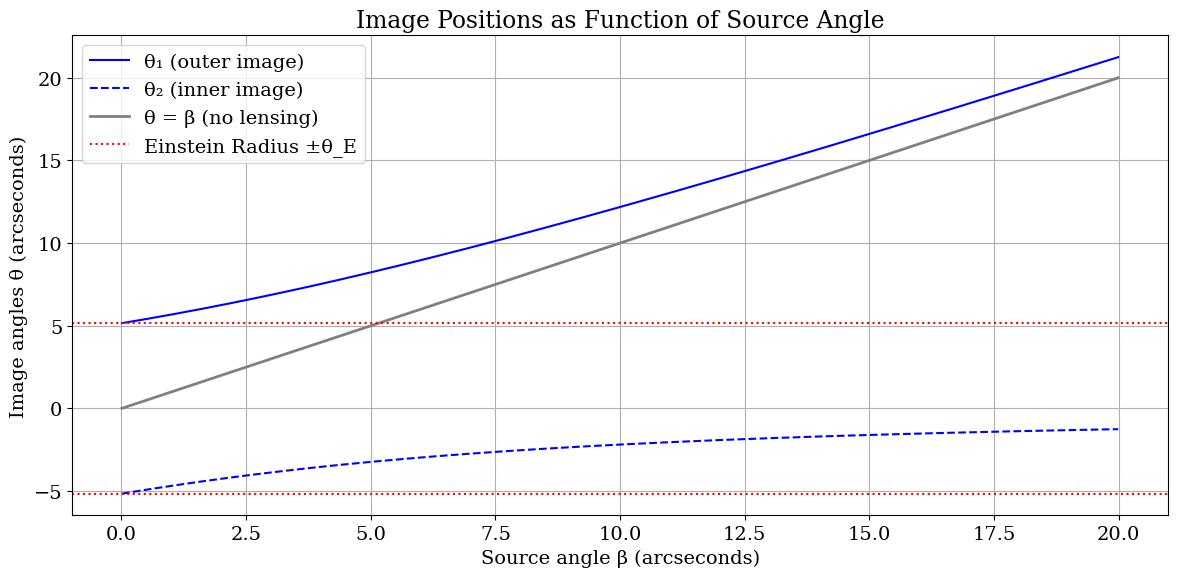

In [66]:

# Parameters
M = 1E12
dL = 5E8
dS = 1E9

# Convert to meters
dL_m = dL * ly
dS_m = dS * ly

# Einstein angle (in radians)
theta_E = np.sqrt((4 * G * M * Msun / c**2) * (dS_m - dL_m) / (dS_m * dL_m))
theta_E_arcsec = theta_E * arcsec_per_radian

betas = np.arange(0.01, 20, 0.01)
theta1s = []
theta2s = []

for beta in betas:
    beta_rad = beta / arcsec_per_radian
    rad_term = np.sqrt(beta_rad**2 + 4 * theta_E**2)
    theta1 = (beta_rad + rad_term) / 2
    theta2 = (beta_rad - rad_term) / 2
    theta1s.append(theta1 * arcsec_per_radian)
    theta2s.append(theta2 * arcsec_per_radian)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(betas, theta1s, label="θ₁ (outer image)", color="blue")
plt.plot(betas, theta2s, label="θ₂ (inner image)", linestyle="--", color="blue")
plt.plot(betas, betas, label="θ = β (no lensing)", color="gray", linewidth=2)
plt.axhline(y=theta_E_arcsec, color='red', linestyle=':', label='Einstein Radius ±θ_E')
plt.axhline(y=-theta_E_arcsec, color='red', linestyle=':')

plt.xlabel("Source angle β (arcseconds)")
plt.ylabel("Image angles θ (arcseconds)")
plt.title("Image Positions as Function of Source Angle")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Additional Plot

1) theta1_offset_source = θ₁ - β: <br>
This gives the angular displacement caused by the lensing effect. A large difference means strong lensing.
<br>
2) theta2s: <br>
The inner image position, which is always closer to the lens than the source (often even on the opposite side if β is small).
<br>
You are plotting: <br>

1)θ₁ - β vs β: showing how the outer image shifts away from the source.<br>

2)θ₂ vs β: showing the behavior of the inner image.



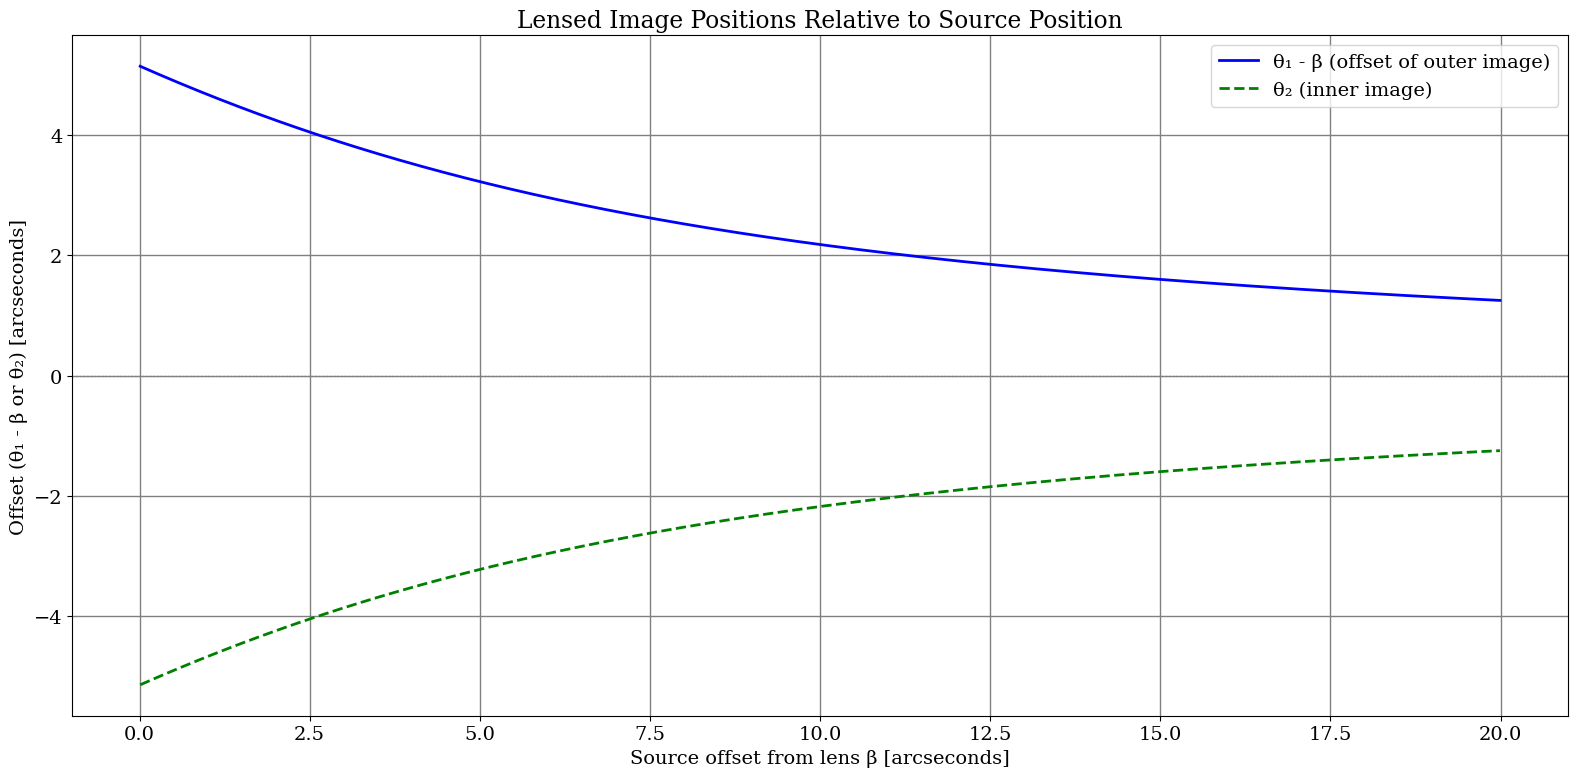

In [70]:
theta1_offset_source = np.array(theta1s) - betas

plt.figure(figsize=(16, 8))
plt.plot(betas, theta1_offset_source, c='blue', linewidth=2, label='θ₁ - β (offset of outer image)')
plt.plot(betas, theta2s, c='green', linewidth=2, linestyle='--', label='θ₂ (inner image)')
plt.axhline(0, color='gray', linestyle=':', linewidth=1)

plt.xlim(np.min(betas)-1, np.max(betas)+1)
plt.ylim(1.1 * np.min(theta2s), 1.1 * np.max(theta1_offset_source))
plt.xlabel('Source offset from lens β [arcseconds]')
plt.ylabel('Offset (θ₁ - β or θ₂) [arcseconds]')
plt.title('Lensed Image Positions Relative to Source Position')
plt.legend()
plt.grid(linestyle='-', linewidth=1, color='gray')
plt.tight_layout()
plt.show()
